<a href="https://colab.research.google.com/github/HoangThai2k5/THDeepLearning/blob/main/Tuan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#
Mô hình hồi quy dự đoán một giá trị số liên tục, DH_Total (tổng điểm trúng tuyển).


## 1. Tải và Khám phá Dữ liệu mới: `dulieuxettuyendaihoc.csv`

Chúng ta sẽ tải tập dữ liệu mới và xem xét 5 dòng đầu tiên, cùng với thông tin tổng quan về các cột và kiểm tra các giá trị thiếu.

In [18]:
import pandas as pd

# Tải dữ liệu mới
df_new = pd.read_csv('/content/dulieuxettuyendaihoc.csv')

# Hiển thị 5 dòng đầu tiên
print("5 dòng đầu tiên của dữ liệu mới:")
display(df_new.head())

# Thông tin tổng quan về dữ liệu
print("\nThông tin dữ liệu mới:")
df_new.info()

# Kiểm tra giá trị thiếu
print("\nKiểm tra giá trị thiếu trong dữ liệu mới:")
display(df_new.isnull().sum())

5 dòng đầu tiên của dữ liệu mới:


,STT,T1,L1,H1,S1,V1,X1,D1,N1,T2,...,X6,D6,N6,GT,DT,KV,DH1,DH2,DH3,KT
0,1,7.2,7.3,6.3,7.3,7.0,7.9,7.3,5.5,8.4,...,6.6,7.6,5.9,F,NaN,2NT,3.25,3.25,4.50,A1
1,2,5.4,3.9,3.9,4.0,5.4,5.4,5.3,2.8,6.3,...,6.6,6.1,4.4,M,NaN,1,6.00,4.00,3.50,C
2,3,5.6,6.8,7.2,7.5,4.3,7.4,5.8,3.2,5.0,...,7.9,8.1,4.6,M,NaN,1,5.00,6.75,4.00,C
3,4,6.6,6.4,5.3,6.9,5.4,7.3,6.4,5.8,5.1,...,7.1,7.3,7.4,M,NaN,1,4.25,4.25,5.25,D1
4,5,6.0,5.0,6.0,7.3,6.5,7.7,7.9,6.1,5.4,...,6.1,7.5,7.2,M,NaN,2NT,4.25,4.50,5.00,A



Thông tin dữ liệu mới:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 56 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   STT     100 non-null    int64  
 1   T1      100 non-null    float64
 2   L1      100 non-null    float64
 3   H1      100 non-null    float64
 4   S1      100 non-null    float64
 5   V1      100 non-null    float64
 6   X1      100 non-null    float64
 7   D1      100 non-null    float64
 8   N1      100 non-null    float64
 9   T2      100 non-null    float64
 10  L2      100 non-null    float64
 11  H2      100 non-null    float64
 12  S2      100 non-null    float64
 13  V2      100 non-null    float64
 14  X2      100 non-null    float64
 15  D2      100 non-null    float64
 16  N2      100 non-null    float64
 17  T3      100 non-null    float64
 18  L3      100 non-null    float64
 19  H3      100 non-null    float64
 20  S3      100 non-null    float64
 21  V3      100 non-

,0
STT,0
T1,0
L1,0
H1,0
S1,0
V1,0
X1,0
D1,0
N1,0
T2,0


## 2. Xử lý giá trị thiếu (Handling Missing Values)

Cột `DT` có tới 97/100 giá trị thiếu, gần như toàn bộ dữ liệu. Vì vậy, chúng ta sẽ loại bỏ cột này để tránh ảnh hưởng đến chất lượng mô hình.

In [19]:
df_new = df_new.drop('DT', axis=1)

print("Kiểm tra giá trị thiếu sau khi loại bỏ cột 'DT':")
display(df_new.isnull().sum())

Kiểm tra giá trị thiếu sau khi loại bỏ cột 'DT':


,0
STT,0
T1,0
L1,0
H1,0
S1,0
V1,0
X1,0
D1,0
N1,0
T2,0


## 3. Tạo biến mục tiêu mới và tiền xử lý dữ liệu

Chúng ta sẽ tạo biến mục tiêu `DH_Total` bằng cách cộng các cột `DH1`, `DH2`, `DH3`. Sau đó, chúng ta cần xử lý các biến phân loại như `GT`, `KV`, `KT` bằng cách mã hóa One-Hot Encoding.

In [20]:
# Tạo biến mục tiêu mới: DH_Total
df_new['DH_Total'] = df_new['DH1'] + df_new['DH2'] + df_new['DH3']

# Loại bỏ các cột điểm DH1, DH2, DH3 ban đầu và cột STT vì không cần thiết cho việc huấn luyện
X = df_new.drop(['STT', 'DH1', 'DH2', 'DH3', 'DH_Total'], axis=1)
y = df_new['DH_Total']

# Xác định các cột phân loại để mã hóa
categorical_cols = ['GT', 'KV', 'KT']

# Thực hiện One-Hot Encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("5 dòng đầu tiên của Features (X) sau khi tiền xử lý:")
display(X.head())
print("\n5 dòng đầu tiên của Target (y) sau khi tạo:")
display(y.head())

5 dòng đầu tiên của Features (X) sau khi tiền xử lý:


,T1,L1,H1,S1,V1,X1,D1,N1,T2,L2,...,X6,D6,N6,GT_M,KV_2,KV_2NT,KT_A1,KT_B,KT_C,KT_D1
0,7.2,7.3,6.3,7.3,7.0,7.9,7.3,5.5,8.4,8.9,...,6.6,7.6,5.9,False,False,True,True,False,False,False
1,5.4,3.9,3.9,4.0,5.4,5.4,5.3,2.8,6.3,5.4,...,6.6,6.1,4.4,True,False,False,False,False,True,False
2,5.6,6.8,7.2,7.5,4.3,7.4,5.8,3.2,5.0,4.9,...,7.9,8.1,4.6,True,False,False,False,False,True,False
3,6.6,6.4,5.3,6.9,5.4,7.3,6.4,5.8,5.1,6.2,...,7.1,7.3,7.4,True,False,False,False,False,False,True
4,6.0,5.0,6.0,7.3,6.5,7.7,7.9,6.1,5.4,5.5,...,6.1,7.5,7.2,True,False,True,False,False,False,False



5 dòng đầu tiên của Target (y) sau khi tạo:


,DH_Total
0,11.00
1,13.50
2,15.75
3,13.75
4,13.75


## 4. Chia dữ liệu thành tập huấn luyện và tập kiểm tra

Chúng ta sẽ chia dữ liệu đã tiền xử lý thành tập huấn luyện và tập kiểm tra để đánh giá hiệu suất của mô hình một cách khách quan.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kích thước tập huấn luyện X_train: {X_train.shape}")
print(f"Kích thước tập kiểm tra X_test: {X_test.shape}")
print(f"Kích thước tập huấn luyện y_train: {y_train.shape}")
print(f"Kích thước tập kiểm tra y_test: {y_test.shape}")

Kích thước tập huấn luyện X_train: (80, 55)
Kích thước tập kiểm tra X_test: (20, 55)
Kích thước tập huấn luyện y_train: (80,)
Kích thước tập kiểm tra y_test: (20,)


## 4.1. Chuẩn hóa dữ liệu (Feature Scaling)

Chúng ta sẽ sử dụng `StandardScaler` để chuẩn hóa các đặc trưng số. Điều này giúp các thuật toán dựa trên khoảng cách (như Hồi quy tuyến tính) hoạt động tốt hơn bằng cách đảm bảo tất cả các đặc trưng có cùng thang đo.

In [22]:
from sklearn.preprocessing import StandardScaler

# Khởi tạo StandardScaler
scaler = StandardScaler()

# Chuẩn hóa X_train (fit và transform)
X_train_scaled = scaler.fit_transform(X_train)

# Chuẩn hóa X_test (chỉ transform, không fit lại để tránh rò rỉ dữ liệu)
X_test_scaled = scaler.transform(X_test)

# Chuyển đổi lại thành DataFrame để dễ nhìn hơn (tùy chọn)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("5 dòng đầu tiên của X_train sau khi chuẩn hóa:")
display(X_train_scaled.head())
print("\n5 dòng đầu tiên của X_test sau khi chuẩn hóa:")
display(X_test_scaled.head())

5 dòng đầu tiên của X_train sau khi chuẩn hóa:


,T1,L1,H1,S1,V1,X1,D1,N1,T2,L2,...,X6,D6,N6,GT_M,KV_2,KV_2NT,KT_A1,KT_B,KT_C,KT_D1
55,1.175277,0.828584,0.490249,0.341681,1.021260,-2.052061,-0.560394,0.665961,1.309828,0.980081,...,-0.171682,0.224198,0.482066,-1.105542,-0.460566,2.0,4.358899,-0.309662,-0.440488,-0.558100
88,-0.448906,0.110677,-1.109144,-0.333244,-1.927198,0.037732,-1.085178,-1.264879,0.098795,0.136093,...,-0.546944,-0.791037,0.204618,0.904534,-0.460566,-0.5,-0.229416,-0.309662,-0.440488,-0.558100
26,-0.629371,-0.846532,-0.900528,-1.008170,-0.690748,-0.968464,0.114328,-0.764291,-0.283637,-0.623496,...,0.503789,0.111394,-0.442761,-1.105542,-0.460566,-0.5,-0.229416,-0.309662,2.270208,-0.558100
42,0.633883,1.227422,0.837943,1.438434,2.638156,1.121329,1.838617,1.095036,0.544965,0.473688,...,1.329365,0.562609,0.574549,-1.105542,-0.460566,-0.5,-0.229416,-0.309662,-0.440488,1.791794
69,0.032333,0.030910,-0.205140,-1.092535,-1.071194,0.424731,-0.410456,-0.192190,-0.092421,-0.454698,...,-0.171682,-2.595897,-0.997657,0.904534,-0.460566,-0.5,-0.229416,3.229330,-0.440488,-0.558100



5 dòng đầu tiên của X_test sau khi chuẩn hóa:


,T1,L1,H1,S1,V1,X1,D1,N1,T2,L2,...,X6,D6,N6,GT_M,KV_2,KV_2NT,KT_A1,KT_B,KT_C,KT_D1
83,-0.027822,-0.128625,0.559788,0.088584,0.545702,1.121329,1.313833,-0.835803,0.672442,0.811283,...,2.004836,0.675413,-0.165313,-1.105542,-0.460566,-0.5,-0.229416,3.229330,-0.440488,-0.5581
53,-0.629371,0.030910,-0.066062,-0.839438,-0.024967,-1.200663,0.489173,0.093860,-0.156159,0.811283,...,-0.922206,-1.242252,0.297101,0.904534,-0.460566,-0.5,-0.229416,-0.309662,-0.440488,-0.5581
70,-0.087977,0.349980,-0.205140,-0.080147,0.735926,0.811730,0.264266,0.308398,0.799919,1.148878,...,0.278632,1.239432,0.759514,-1.105542,2.171241,-0.5,-0.229416,-0.309662,-0.440488,-0.5581
45,0.573728,-0.447695,0.559788,-0.755073,1.021260,1.430928,-0.110579,0.665961,-0.602329,-1.129888,...,-0.847153,0.449805,-0.257796,-1.105542,2.171241,-0.5,-0.229416,-0.309662,-0.440488,-0.5581
44,0.092488,0.828584,-0.274678,0.004218,0.070145,0.347331,0.339235,0.880498,1.564782,0.811283,...,-0.246735,0.111394,1.221928,-1.105542,-0.460566,2.0,-0.229416,-0.309662,-0.440488,-0.5581


## 5. Huấn luyện mô hình Hồi quy tuyến tính

Chúng ta sẽ sử dụng mô hình Hồi quy tuyến tính để dự đoán tổng điểm DH.

## 5. Huấn luyện mô hình Hồi quy tuyến tính (trên dữ liệu đã chuẩn hóa)

Chúng ta sẽ sử dụng mô hình Hồi quy tuyến tính để dự đoán tổng điểm DH, lần này trên dữ liệu đã được chuẩn hóa.

In [23]:
# Huấn luyện mô hình trên tập huấn luyện đã chuẩn hóa
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

print("Mô hình Hồi quy tuyến tính đã được huấn luyện với biến mục tiêu DH_Total trên dữ liệu đã chuẩn hóa.")

Mô hình Hồi quy tuyến tính đã được huấn luyện với biến mục tiêu DH_Total trên dữ liệu đã chuẩn hóa.


## 6. Đánh giá mô hình

Đánh giá hiệu suất của mô hình trên tập kiểm tra bằng các chỉ số MAE, MSE, RMSE và R-squared.

## 6. Đánh giá mô hình (trên dữ liệu đã chuẩn hóa)

Đánh giá hiệu suất của mô hình trên tập kiểm tra đã chuẩn hóa bằng các chỉ số MAE, MSE, RMSE và R-squared.

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

print("\nGiải thích các chỉ số:")
print("MAE: Sai số tuyệt đối trung bình. Giá trị thấp hơn tốt hơn.")
print("MSE: Sai số bình phương trung bình. Giá trị thấp hơn tốt hơn.")
print("RMSE: Căn bậc hai của MSE. Có cùng đơn vị với biến mục tiêu.")
print("R2: Hệ số xác định. Giá trị càng gần 1 càng tốt.")

Mean Absolute Error (MAE): 1.95
Mean Squared Error (MSE): 6.19
Root Mean Squared Error (RMSE): 2.49
R-squared (R2): -1.12

Giải thích các chỉ số:
MAE: Sai số tuyệt đối trung bình. Giá trị thấp hơn tốt hơn.
MSE: Sai số bình phương trung bình. Giá trị thấp hơn tốt hơn.
RMSE: Căn bậc hai của MSE. Có cùng đơn vị với biến mục tiêu.
R2: Hệ số xác định. Giá trị càng gần 1 càng tốt.


In [27]:
y_pred_scaled = model_scaled.predict(X_test_scaled)

mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

print(f"Mean Absolute Error (MAE) sau chuẩn hóa: {mae_scaled:.2f}")
print(f"Mean Squared Error (MSE) sau chuẩn hóa: {mse_scaled:.2f}")
print(f"Root Mean Squared Error (RMSE) sau chuẩn hóa: {rmse_scaled:.2f}")
print(f"R-squared (R2) sau chuẩn hóa: {r2_scaled:.2f}")

print("\nSo sánh với kết quả trước khi chuẩn hóa:")
print(f"R2 trước chuẩn hóa: {r2:.2f}")
print(f"R2 sau chuẩn hóa: {r2_scaled:.2f}")

Mean Absolute Error (MAE) sau chuẩn hóa: 1.95
Mean Squared Error (MSE) sau chuẩn hóa: 6.19
Root Mean Squared Error (RMSE) sau chuẩn hóa: 2.49
R-squared (R2) sau chuẩn hóa: -1.12

So sánh với kết quả trước khi chuẩn hóa:
R2 trước chuẩn hóa: -1.12
R2 sau chuẩn hóa: -1.12


## 7. Huấn luyện mô hình Random Forest Regressor

Sau khi thấy mô hình Hồi quy tuyến tính không hiệu quả, chúng ta sẽ thử một mô hình mạnh mẽ hơn là Random Forest Regressor.

In [25]:
from sklearn.ensemble import RandomForestRegressor

# Khởi tạo mô hình Random Forest Regressor
# random_state để đảm bảo kết quả có thể lặp lại
rf_model = RandomForestRegressor(random_state=42)

# Huấn luyện mô hình trên tập huấn luyện đã chuẩn hóa
rf_model.fit(X_train_scaled, y_train)

print("Mô hình Random Forest Regressor đã được huấn luyện.")

Mô hình Random Forest Regressor đã được huấn luyện.


## 8. Đánh giá mô hình Random Forest Regressor

Đánh giá hiệu suất của mô hình Random Forest trên tập kiểm tra đã chuẩn hóa.

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Dự đoán trên tập kiểm tra đã chuẩn hóa
rf_y_pred = rf_model.predict(X_test_scaled)

# Tính toán các chỉ số đánh giá
rf_mae = mean_absolute_error(y_test, rf_y_pred)
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_y_pred)

print(f"Random Forest - Mean Absolute Error (MAE): {rf_mae:.2f}")
print(f"Random Forest - Mean Squared Error (MSE): {rf_mse:.2f}")
print(f"Random Forest - Root Mean Squared Error (RMSE): {rf_rmse:.2f}")
print(f"Random Forest - R-squared (R2): {rf_r2:.2f}")

print("\nSo sánh R2:")
print(f"Linear Regression (sau chuẩn hóa) R2: {r2_scaled:.2f}")
print(f"Random Forest R2: {rf_r2:.2f}")

Random Forest - Mean Absolute Error (MAE): 1.24
Random Forest - Mean Squared Error (MSE): 1.76
Random Forest - Root Mean Squared Error (RMSE): 1.33
Random Forest - R-squared (R2): 0.40

So sánh R2:
Linear Regression (sau chuẩn hóa) R2: -1.12
Random Forest R2: 0.40


## 9. Trực quan hóa kết quả: Hồi quy tuyến tính và Random Forest

Chúng ta sẽ vẽ biểu đồ phân tán giữa giá trị thực tế và giá trị dự đoán cho cả hai mô hình để so sánh trực quan hiệu suất của chúng.

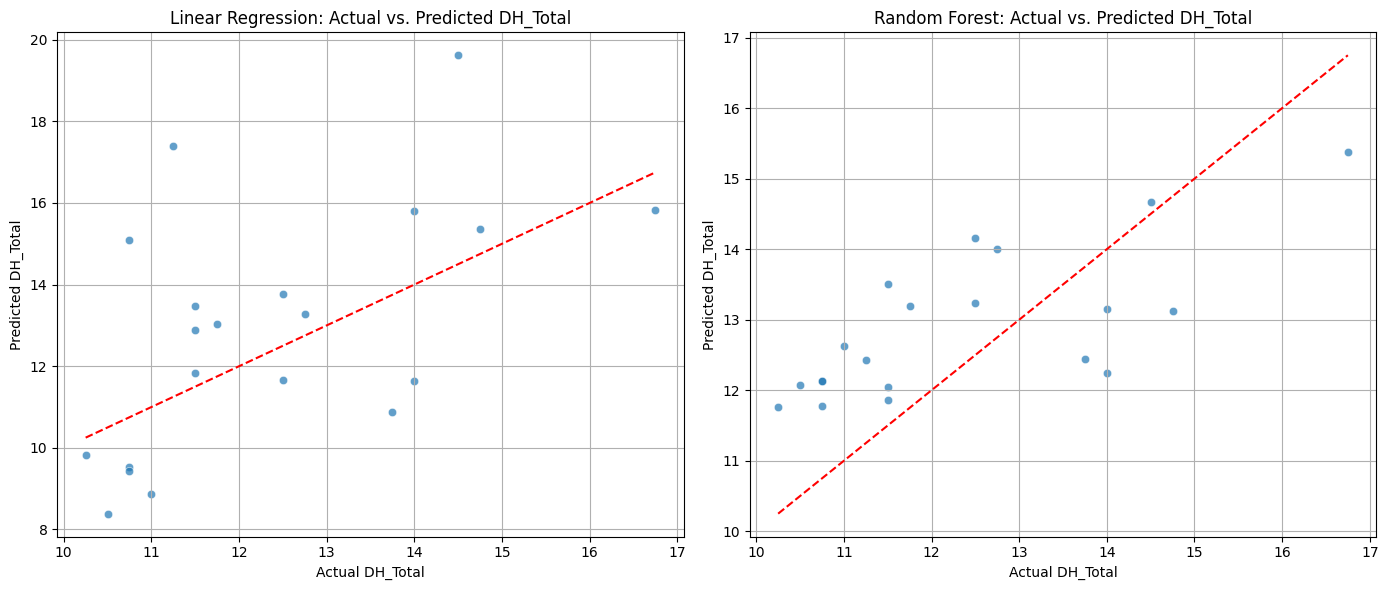

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Biểu đồ cho Hồi quy tuyến tính
plt.subplot(1, 2, 1) # 1 hàng, 2 cột, biểu đồ thứ nhất
sns.scatterplot(x=y_test, y=y_pred_scaled, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--') # Đường y=x
plt.title('Linear Regression: Actual vs. Predicted DH_Total')
plt.xlabel('Actual DH_Total')
plt.ylabel('Predicted DH_Total')
plt.grid(True)

# Biểu đồ cho Random Forest
plt.subplot(1, 2, 2) # 1 hàng, 2 cột, biểu đồ thứ hai
sns.scatterplot(x=y_test, y=rf_y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--') # Đường y=x
plt.title('Random Forest: Actual vs. Predicted DH_Total')
plt.xlabel('Actual DH_Total')
plt.ylabel('Predicted DH_Total')
plt.grid(True)

plt.tight_layout() # Đảm bảo các biểu đồ không chồng chéo
plt.show()